In [1]:
!mkdir wmt16

In [2]:
!pip install sacremoses
!pip install subword-nmt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 15.3 MB/s eta 0:00:00


# transformer翻译实战

In [3]:
!sh data_multi30k.sh wmt16 wmt16 de en
#处理完成

[train] 源语言文本分词完成
[train] 目标语言文本分词完成
[val] 源语言文本分词完成
[val] 目标语言文本分词完成
[test] 源语言文本分词完成
[test] 目标语言文本分词完成
100% 20000/20000 [00:22<00:00, 881.27it/s]
Finished applying bpe to train files.
Finished applying bpe to val files.
Finished applying bpe to test files.


In [119]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

sys.version_info(major=3, minor=11, micro=13, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1
torch 2.6.0+cu124
cuda:0


# 编写dataset

In [120]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader


In [121]:
class LangPairDataset(Dataset):
    def __init__(self,mode="train",max_length=128,overwrite_cache_flag=False,data_dir="wmt16"):
        self.data_dir = Path(data_dir)
        cache_path = self.data_dir / ".cache" /f"de2en_{mode}_max{max_length}.npy"
        if not cache_path.exists() or overwrite_cache_flag:
            cache_path.parent.mkdir(parents=True,exist_ok=True)
            print(f"Cache file {cache_path} not found or overwrite_cache_flag is True, processing data...")
            with open(self.data_dir / f"{mode}_src.bpe","r",encoding="utf-8") as f:
                src_lines = f.readlines()
            with open(self.data_dir / f"{mode}_trg.bpe","r",encoding="utf-8") as f:
                trg_lines = f.readlines()
            assert len(src_lines) == len(trg_lines),f"The number of source and target lines are not equal: {len(src_lines)} != {len(trg_lines)}"

            filtered_src_lines = []
            filtered_trg_lines = []

            for src_line,trg_line in tqdm(zip(src_lines,trg_lines),total=len(src_lines),desc="Processing data"):
                src_line = src_line.strip()
                trg_line = trg_line.strip()
                if len(src_line.split()) <= max_length and len(trg_line.split()) <= max_length:
                    filtered_src_lines.append(src_line)
                    filtered_trg_lines.append(trg_line)
            np.save(
                cache_path,
                {
                    "src_lines":filtered_src_lines,
                    "trg_lines":filtered_trg_lines,
                }
            )
            print(f"Data has been processed and saved to {cache_path}")
        else:
            print(f"Loading cached data from {cache_path}...")
            cache_dict = np.load(cache_path,allow_pickle=True).item()
            filtered_src_lines = cache_dict["src_lines"]
            filtered_trg_lines = cache_dict["trg_lines"]
        self.src_lines = filtered_src_lines
        self.trg_lines = filtered_trg_lines

    def __getitem__(self,idx):
        src_line = self.src_lines[idx]
        trg_line = self.trg_lines[idx]
        return src_line,trg_line

    def __len__(self):
        return len(self.src_lines)

train_ds = LangPairDataset(mode="train")
val_ds = LangPairDataset(mode="val")

Loading cached data from wmt16/.cache/de2en_train_max128.npy...
Loading cached data from wmt16/.cache/de2en_val_max128.npy...


In [122]:
# 测试train_ds, val_ds是否载入正常
print(f"train_ds size: {len(train_ds)}")
print(f"val_ds size: {len(val_ds)}")

# 随机抽取几条样本查看
for i in range(3):
    src, trg = train_ds[i]
    print(f"[train_ds][{i}] src: {src}")
    print(f"[train_ds][{i}] trg: {trg}")

for i in range(3):
    src, trg = val_ds[i]
    print(f"[val_ds][{i}] src: {src}")
    print(f"[val_ds][{i}] trg: {trg}")



train_ds size: 29000
val_ds size: 1014
[train_ds][0] src: zwei junge weiße männer sind im freien in der nähe vieler büsche .
[train_ds][0] trg: two young , white males are outside near many bushes .
[train_ds][1] src: mehrere männer mit schutzhelmen bedienen ein an@@ trie@@ bs@@ rad@@ system .
[train_ds][1] trg: several men in hard hats are operating a giant pulley system .
[train_ds][2] src: ein kleines mädchen klettert in ein spielhaus aus holz .
[train_ds][2] trg: a little girl climbing into a wooden playhouse .
[val_ds][0] src: eine gruppe von männern lädt baum@@ wolle auf einen lastwagen
[val_ds][0] trg: a group of men are loading cotton onto a truck
[val_ds][1] src: ein mann schläft in einem grünen raum auf einem sofa .
[val_ds][1] trg: a man sleeping in a green room on a couch .
[val_ds][2] src: ein junge mit kopfhörern sitzt auf den schultern einer frau .
[val_ds][2] trg: a boy wearing headphones sits on a woman &apos;s shoulders .


# 实现tokenizer
共享词典版本

In [123]:
word2idx = {
    "[PAD]":0,
    "[BOS]":1,
    "[UNK]":2,
    "[EOS]":3,
}
idx2word = {v:k for k,v in word2idx.items()}

index = len(idx2word)
threshold = 1 # 设置阈值，低于阈值的词将被替换为"[UNK]"
with open("wmt16/vocab","r",encoding="utf-8") as f:
    for line in tqdm(f.readlines()):
        token ,counts = line.strip().split()
        if int(counts) >= threshold:
            word2idx[token] = index
            idx2word[index] = token
            index += 1
vocab_size = len(idx2word)
print(f"Vocabulary size: {vocab_size}")

  0%|          | 0/18107 [00:00<?, ?it/s]

Vocabulary size: 18111


In [124]:
class Tokenizer:
    def __init__(self,word2idx,idx2word,max_length=128,pad_idx=0,bos_idx=1,unk_idx=2,eos_idx=3):
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.unk_idx = unk_idx
        self.eos_idx = eos_idx

    def encode(self,text_list,padding_first=False,add_bos=True,add_eos=True,return_mask_flag=False):
        text_max_length = max([len(text.split()) for text in text_list])
        extra = int(add_bos) + int(add_eos)
        max_length = min(text_max_length + extra,self.max_length)
        encoded_list = []
        for text in text_list:
            tokens = text.split()
            encoded=[self.word2idx.get(token,self.unk_idx) for token in tokens[:max_length-extra]]
            if add_bos:
                encoded = [self.bos_idx] + encoded
            if add_eos:
                encoded = encoded + [self.eos_idx]
            if not padding_first:
                encoded = encoded + [self.pad_idx] * (max_length - len(encoded))
            else:
                encoded = [self.pad_idx] * (max_length - len(encoded)) + encoded
            encoded_list.append(encoded)#shape: (batch_size,seq_len)
        input_idx = torch.tensor(encoded_list)
        masks = (input_idx == self.pad_idx).to(dtype=torch.int64)
        return input_idx if not return_mask_flag else (input_idx,masks)

    def decode(self,indices_list,remove_bos=True,remove_eos=True,remove_padding=True,split=False,padding_first=False):
        text_list = []
        indices_list = indices_list.cpu().numpy()
        for indices in indices_list:
            text = []
            for idx in indices:
                word = self.idx2word.get(idx,"[UNK]")
                # print(word)
                if remove_bos and idx == self.bos_idx:
                    continue
                elif remove_eos and idx == self.eos_idx:
                    break
                elif remove_padding and idx == self.pad_idx and not padding_first:
                    break
                text.append(word)
            if not split:
                text = " ".join(text)
            text_list.append(text)
        return text_list
tokenizer = Tokenizer(word2idx,idx2word)

In [ ]:
# # # 测试tokenizer是否正常，先用三句话测试
# test_sentences = [
#     "zwei junge weiße männer sind im freien in der nähe viel@@ er bü@@ sche .",
#     "mehrere männer mit schutzhelmen bedienen ein an@@ trie@@ b@@ s@@ rad@@ system .",
#     "ein kleines mädchen klettert in ein spiel@@ haus aus holz ."
# ]

# # 编码测试
# encoded = tokenizer.encode(test_sentences,return_mask_flag=True)
# print("Encoded:")
# print(encoded)
# # 写一个循环，把3个都decode了
# if isinstance(encoded, tuple):
#     encoded_tensor = encoded[0]
# else:
#     encoded_tensor = encoded
# print(f"masks: {encoded[1]}")
# decoded = tokenizer.decode(encoded_tensor.tolist(), remove_bos=True, remove_eos=True, remove_padding=True)
# print("Decoded:")
# for text in decoded:
#     print(text)

# #德文测试通过


# # 用同样的格式进行英文测试
# test_sentences_en = [
#     "two young , white males are outside near many bushes .",
#     "several men in hard hats are operating a giant pul@@ ley system .",
#     "a little girl climbing into a wooden play@@ house ."
# ]

# # 编码测试
# encoded_en = tokenizer.encode(test_sentences_en, return_mask_flag=True)
# print("Encoded (EN):")
# print(encoded_en)
# # 写一个循环，把3个都decode了
# if isinstance(encoded_en, tuple):
#     encoded_tensor_en = encoded_en[0]
# else:
#     encoded_tensor_en = encoded_en
# print(f"masks (EN): {encoded_en[1]}")
# decoded_en = tokenizer.decode(encoded_tensor_en.tolist(), remove_bos=True, remove_eos=True, remove_padding=True)
# print("Decoded (EN):")
# for text in decoded_en:
#     print(text)

# # 英文测试通过


# transformer_batch_sample实现

In [126]:
class SampleInfo:
    def __init__(self,i,lens):
        """
        初始化一个样本信息类
        Args:
            i: 样本索引
            lens: 源语言和目标语言的句子长度列表,第一个元素是源语言长度,第二个元素是目标语言长度
        """
        self.i = i
        self.max_len = max(lens[0],lens[1])
        self.src_len = lens[0]+1
        self.trg_len = lens[1]+1


class TokenBatchCreator:
    def __init__(self,batch_size):
        self._batch = []
        self.max_len = -1
        self._batch_size = batch_size

    def append(self, info):
        cur_len = info.max_len
        max_len = max(self.max_len,cur_len)
        if max_len * (len(self._batch)+1) > self._batch_size:#如果batch中最大的句子长度乘以当前batch的样本数大于batch_size，则返回当前batch
            self._batch, result = [], self._batch
            self._batch.append(info)
            self.max_len = cur_len
            return result
        else:
            self.max_len = max_len
            self._batch.append(info)
            return None

    @property
    def get_batch(self):
        return self._batch

In [127]:
# 测试SampleInfo和TokenBatchCreator类

# 构造一些样本的长度信息
sample_lens = [
    (5, 7),   # src_len=5, trg_len=7
    (8, 6),
    (3, 4),
    (10, 9),
    (2, 2),
    (7, 8)
]

# 创建SampleInfo对象列表
sample_infos = [SampleInfo(i, lens) for i, lens in enumerate(sample_lens)]

# 设置batch_size为100（即最大token数为100）
batch_size = 100
batch_creator = TokenBatchCreator(batch_size)

batches = []
for info in sample_infos:
    result = batch_creator.append(info)
    if result is not None:
        batches.append(result)
# 最后一个batch可能没有被返回
if batch_creator.get_batch:
    batches.append(batch_creator.get_batch)

# 打印每个batch的样本索引和最大长度
for idx, batch in enumerate(batches):
    print(f"Batch {idx}:")
    for info in batch:
        print(f"  Sample idx: {info.i}, src_len: {info.src_len}, trg_len: {info.trg_len}, max_len: {info.max_len}")
    print("-----")


Batch 0:
  Sample idx: 0, src_len: 6, trg_len: 8, max_len: 7
  Sample idx: 1, src_len: 9, trg_len: 7, max_len: 8
  Sample idx: 2, src_len: 4, trg_len: 5, max_len: 4
  Sample idx: 3, src_len: 11, trg_len: 10, max_len: 10
  Sample idx: 4, src_len: 3, trg_len: 3, max_len: 2
  Sample idx: 5, src_len: 8, trg_len: 9, max_len: 8
-----


## 实现TransformerBatchsampler

In [128]:
from torch.utils.data import BatchSampler
import numpy as np


In [129]:
class TransformerBatchSampler(BatchSampler):
    def __init__(
        self,
        dataset,
        batch_size,
        shuffle_batch=False,
        clip_last_batch=True,
        seed=0
    ):
        """
        初始化一个TransformerBatchSampler类
        Args:
            dataset: 数据集
            batch_size: 每个batch的大小
            shuffle_batch: 是否打乱batch
            clip_last_batch: 是否截断最后一个batch,如果为True,则最后一个batch可能远小于batch_size
            seed: 随机种子
        """
        self._dataset = dataset
        self._batch_size = batch_size
        self._shuffle_batch = shuffle_batch
        self._clip_last_batch = clip_last_batch
        self._seed = seed
        self._random = np.random
        self._random.seed(seed)

        self._sample_infos = []
        for i ,data in enumerate(self._dataset):
            lens = [len(data[0]),len(data[1])]
            self._sample_infos.append(SampleInfo(i,lens))

    def __iter__(self):
        infos = sorted(self._sample_infos,key=lambda x:(x.src_len,x.trg_len))
        batch_infos = []
        batch_creator = TokenBatchCreator(self._batch_size)
        for info in infos:
            batch = batch_creator.append(info)
            if batch is not None:
                batch_infos.append(batch)

        if self._clip_last_batch:
            batch_infos.append(batch_creator.get_batch)
        if self._shuffle_batch:
            self._random.shuffle(batch_infos)
        self.batch_number = len(batch_infos)
        for batch in batch_infos:
            yield [info.i for info in batch]

    def __len__(self):
        if hasattr(self,"batch_number"):
            return self.batch_number
        else:
            batch_number = (len(self._dataset) + self._batch_size ) // self._batch_size
            return batch_number

In [130]:

#测试成功
sampler = TransformerBatchSampler(train_ds, batch_size=4096, shuffle_batch=True)
for idx, batch in enumerate(sampler):
    print("第{}批量的数据中含有文本对是：{}，数量为：{}".format(idx, batch, len(batch)))
    if idx >= 3:
        break
for idx, batch in enumerate(sampler):
    print("第{}批量的数据中含有文本对是：{}，数量为：{}".format(idx, batch, len(batch)))
    # 打印前三对文本对
    for i in range(min(3, len(batch))):
        src, trg = train_ds[batch[i]]
        print(f"  第{i+1}对: 源句: {src}")
        print(f"         目标句: {trg}")
    if idx >= 3:
        break

第0批量的数据中含有文本对是：[28754, 1401, 2733, 15505, 15571, 3573, 5327, 5917, 19945, 3432, 23159, 4539, 19061, 23115, 27487, 27879, 17089, 17465, 16955, 24107, 20551, 11605, 20980, 8784, 8043, 11661, 13025, 24046, 27884, 10623, 5069, 7081, 16797, 16867]，数量为：34
第1批量的数据中含有文本对是：[17378, 17417, 10201, 25096, 2135, 7065, 21351, 5742, 13555, 24205, 4248, 21191, 18844, 25108, 10272, 14283, 18349, 22228, 23447, 2037, 14393, 17495, 24949, 26031, 26331, 28020, 10817, 11163, 14252, 21933, 27076, 17073, 23461, 3116, 7232, 7827, 11470, 17891, 20803, 21160, 25699, 2114]，数量为：42
第2批量的数据中含有文本对是：[18986, 22444, 23178, 23696, 24026, 26552, 27566, 28870, 4254, 4322, 6348, 7292, 7460, 8138, 8166, 8366, 8530, 9362, 9903, 10285, 12201, 14588, 14734, 14983, 15302, 15548, 16164, 16203, 16378, 17482, 17928, 19080, 19634, 20250, 21144, 21242, 21936, 23134, 25404, 26186, 28624, 5680, 6300, 6477, 6536, 7376, 7534, 7660, 7883, 9954, 10136, 13663, 16048, 17418, 17710, 18630, 21306, 21425, 21866, 24409, 27272, 878, 1138, 1280, 14

## dataloader

In [131]:
def collate_fct(batch, tokenizer):
    src_words = [pair[0] for pair in batch]
    trg_words = [pair[1] for pair in batch]

    # print(src_words)
    # print(trg_words)

    encoder_inputs, encoder_inputs_mask = tokenizer.encode(src_words,add_bos=True,add_eos=True,return_mask_flag=True)

    decoder_labels, decoder_labels_mask = tokenizer.encode(trg_words,add_bos=False,add_eos=True,return_mask_flag=True)

    decoder_inputs,_ = tokenizer.encode(trg_words,add_bos=True,add_eos=False,return_mask_flag=True)
    # print(f"decoder_inputs: {type(decoder_inputs)}")
    # print(f"decoder_labels: {type(decoder_labels)}")
    return {
        "encoder_inputs":encoder_inputs.to(device=device),
        "encoder_inputs_mask":encoder_inputs_mask.to(device=device),
        "decoder_labels":decoder_labels.to(device=device),
        "decoder_labels_mask":decoder_labels_mask.to(device=device),
        "decoder_inputs":decoder_inputs.to(device=device)
    }

In [132]:
# 构造一个batch，包含3个德语-英语句对，每个元素为list
test_batch = [
    ["zwei junge weiße männer sind im freien in der nähe vieler büsche .", "two young , white males are outside near many bushes ."],
    ["mehrere männer mit schutzhelmen bedienen ein antriebsradsystem .", "several men in hard hats are operating a giant pulley system ."],
    ["ein kleines mädchen klettert in ein spielhaus aus holz .", "a little girl climbing into a wooden playhouse ."]
]

# 假设你已经有tokenizer对象
# 这里以tokenizer为变量名，实际使用时请确保tokenizer已定义并加载好词表

collate_result = collate_fct(test_batch, tokenizer)

# 打印结果，查看各个字段的shape和内容
for k, v in collate_result.items():
    print(f"{k}: {v}")

# #测试通过

encoder_inputs: tensor([[    1,    29,    44,   503,    58,   172,    34,   181,     6,    24,
           220, 13388,  7503,     4,     3],
        [    1,   148,    58,    13,  1834,  4929,     7,     2,     4,     3,
             0,     0,     0,     0,     0],
        [    1,     7,   123,    43,   453,     6,     7, 13389,   104,  1063,
             4,     3,     0,     0,     0]], device='cuda:0')
encoder_inputs_mask: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]], device='cuda:0')
decoder_labels: tensor([[   28,    38,     9,    40,  1580,    30,   111,   151,   372,  2931,
             4,     3,     0],
        [  209,    51,     6,   628,   530,    30,  2578,     5,  1459, 12584,
          4930,     4,     3],
        [    5,   105,    54,   420,   130,     5,   460, 12585,     4,     3,
             0,     0,     0]], device='cuda:0')
decoder_labels_mask: tenso

In [133]:
from functools import partial
sampler = TransformerBatchSampler(train_ds,batch_size=256,shuffle_batch=True)

sample_dl = DataLoader(train_ds,batch_sampler=sampler,collate_fn=partial(collate_fct,tokenizer=tokenizer))

for batch in sample_dl:
    for key, value in batch.items():
        print(key)
        # print(value)
        print(tokenizer.decode(value))
    break


#测试通过

encoder_inputs
['eine frau und ein mann schneiden zusammenger@@ ollten teig in kleine stücke .', 'ein gruppe von boots@@ fahrern fährt einen gewun@@ denen wasserlauf entlang .', 'eine frau in einer blauen jacke , die in wassernähe ein braunes pony reitet .']
encoder_inputs_mask
['', '', '']
decoder_labels
['a woman and man cut rolled up dough into small pieces .', 'a group of bo@@ aters boating down a winding waterway .', 'a woman in a blue jacket rides a brown pony near water .']
decoder_labels_mask
['', '', '']
decoder_inputs
['a woman and man cut rolled up dough into small pieces .', 'a group of bo@@ aters boating down a winding waterway .', 'a woman in a blue jacket rides a brown pony near water .']


# 定义模型

## embedding

In [ ]:
class TransformerEmbedding(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.vocab_size = config["vocab_size"]
        self.hidden_size = config["hidden_size"]
        self.pad_idx = config["pad_idx"]
        dropout_rate = config["dropout_rate"]
        self.max_length = config["max_length"]# max_lenegth是位置编码的最大长度

        self.word_embedding = nn.Embedding(self.vocab_size,self.hidden_size,padding_idx=self.pad_idx)# 词嵌入层
        self.pos_embedding = nn.Embedding(self.max_length,self.hidden_size,_weight=self.get_positional_encoding(
            self.max_length,self.hidden_size
        ))# 位置嵌入层
        self.pos_embedding.weight.requires_grad_(False)
        self.dropout = nn.Dropout(dropout_rate)

    def get_word_embedding(self):
        return self.word_embedding.weight #shape: (vocab_size,hidden_size)

    @classmethod
    def get_positional_encoding(self, max_length,hidden_size):
        pe = torch.zeros(max_length,hidden_size)
        position = torch.arange(0,max_length,dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0,hidden_size,2).float() * (-torch.log(torch.tensor(10000.0)) / hidden_size))
        pe[:,0::2] = torch.sin(position * div_term)
        pe[:,1::2] = torch.cos(position * div_term)

        return pe

    def forward(self,input_ids):
        seq_len = input_ids.shape[1]#type(input_ids)=torch.Tensor,input_ids.shape=(batch_size,seq_len)
        input_ids = input_ids.to(device)
        assert(
            seq_len<=self.max_length
        ), f"input_ids shape is {input_ids.shape}, but seq_len is {seq_len}, which is greater than max_length {self.max_length}"

        position_ids = torch.arange(seq_len,dtype=torch.long,device=input_ids.device).to(device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids).to(device)# 扩展到和input_ids一样的形状

        word_embeds =self.word_embedding(input_ids)# 词嵌入
        pos_embeds=self.pos_embedding(position_ids)# 位置嵌入
        embeds = word_embeds+pos_embeds  #shape: (batch_size,seq_len,hidden_size)
        embeds = self.dropout(embeds)# 丢弃
        return embeds.to(device)



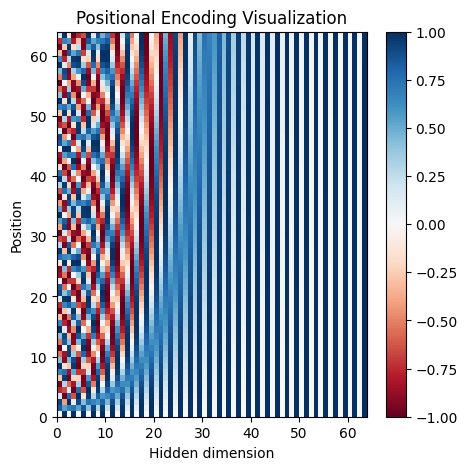

In [135]:
import matplotlib.pyplot as plt

# 假设hidden_size为32, max_length为100
hidden_size = 64
max_length = 64

# 获取位置编码
pe = TransformerEmbedding.get_positional_encoding(max_length, hidden_size)

# 绘制位置编码
plt.figure(figsize=(5, 5))
plt.pcolormesh(pe, cmap='RdBu')
plt.xlabel('Hidden dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Visualization')
plt.colorbar()
plt.show()



## Multi-Head Attention

In [136]:
from dataclasses import dataclass
from typing import Optional, Tuple # 导入Optional和Tuple,Optional表示可选参数,代表参数可以为空,Tuple表示元组,代表参数可以为多个

In [ ]:
Tensor = torch.Tensor

@dataclass
class AttentionOutput:
    hidden_states: Tensor
    attn_scores: Tensor

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.hidden_size = config["hidden_size"]# 隐藏层大小
        self.num_heads = config["num_heads"]# 头数
        self.head_size = self.hidden_size // self.num_heads# 每个头的大小

        assert(
            self.hidden_size % self.num_heads == 0
        ),f"hidden_size must be divisible by num_heads, but got {self.hidden_size} and {self.num_heads}"

        self.head_dim = self.hidden_size // self.num_heads# 每个头的大小

        self.q_proj = nn.Linear(self.hidden_size,self.hidden_size, bias=False)# 查询投影
        self.k_proj = nn.Linear(self.hidden_size,self.hidden_size, bias=False)# 键投影
        self.v_proj = nn.Linear(self.hidden_size,self.hidden_size, bias=False)# 值投影

        self.out_proj = nn.Linear(self.hidden_size,self.hidden_size, bias=False)# 输出投影

    def _split_heads(self,tensor:Tensor)->Tensor:
        """
        将最后一个维度拆分成num_heads和head_dim
        """
        batch_size, seq_len, _ = tensor.shape
        return tensor.view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        #shape: (batch_size, seq_len, hidden_size)->(batch_size, seq_len, num_heads, head_dim)->(batch_size, num_heads, seq_len, head_dim)

    def _merge_heads(self,tensor:Tensor)->Tensor:
        """
        将最后一个维度合并成一个维度
        """
        batch_size, num_heads, seq_len, head_dim = tensor.shape
        return tensor.permute(0, 2, 1, 3).contiguous().reshape(batch_size, seq_len, self.hidden_size)
        #shape: (batch_size, num_heads, seq_len, head_dim)->(batch_size, seq_len, hidden_size)

    def forward(self,querys, keys ,values ,attn_mask=None)->AttentionOutput:

        query = self._split_heads(self.q_proj(querys))#shape: (batch_size, seq_len, hidden_size)->(batch_size, seq_len, num_heads, head_dim)->(batch_size, num_heads, seq_len, head_dim)
        key = self._split_heads(self.k_proj(keys))#shape: (batch_size, seq_len, hidden_size)->(batch_size, seq_len, num_heads, head_dim)->(batch_size, num_heads, seq_len, head_dim)
        value = self._split_heads(self.v_proj(values))#shape: (batch_size, seq_len, hidden_size)->(batch_size, seq_len, num_heads, head_dim)->(batch_size, num_heads, seq_len, head_dim)
        #shape: (batch_size, seq_len, hidden_size)->(batch_size, seq_len, num_heads, head_dim)->(batch_size, num_heads, seq_len, head_dim)

        qk_logits = torch.matmul(query, key.transpose(-2, -1)) #shape: (batch_size, num_heads, seq_len_q, head_dim)->(batch_size, num_heads, seq_len_q, seq_len_k)

        if attn_mask is not None:
            attn_mask = attn_mask[:,:,:querys.shape[-2],:keys.shape[-2]]
            qk_logits += attn_mask * -1e9
        attn_scores = F.softmax(qk_logits / (self.head_dim ** 0.5), dim=-1)# shape: (batch_size, num_heads, seq_len_q, seq_len_k)

        embeds = torch.matmul(attn_scores, value)
        embeds = self.out_proj(self._merge_heads(embeds))
        return AttentionOutput(hidden_states=embeds, attn_scores=attn_scores)




hidden_states shape: torch.Size([2, 5, 16])
attn_scores shape: torch.Size([2, 4, 5, 5])
With mask - hidden_states shape: torch.Size([2, 5, 16])
With mask - attn_scores shape: torch.Size([2, 4, 5, 5])


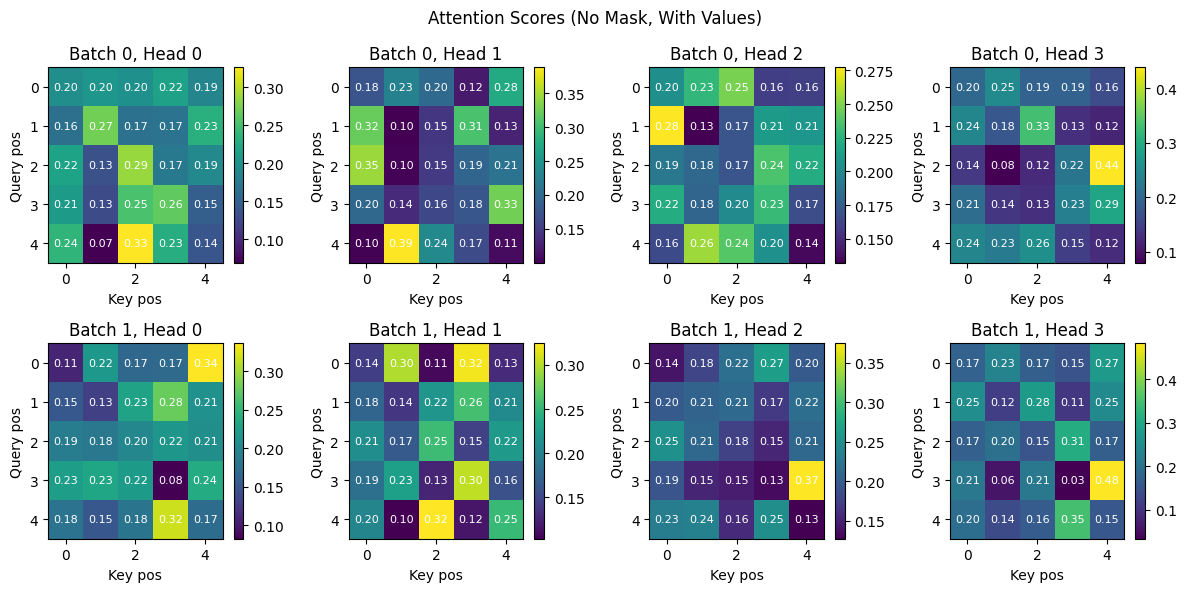

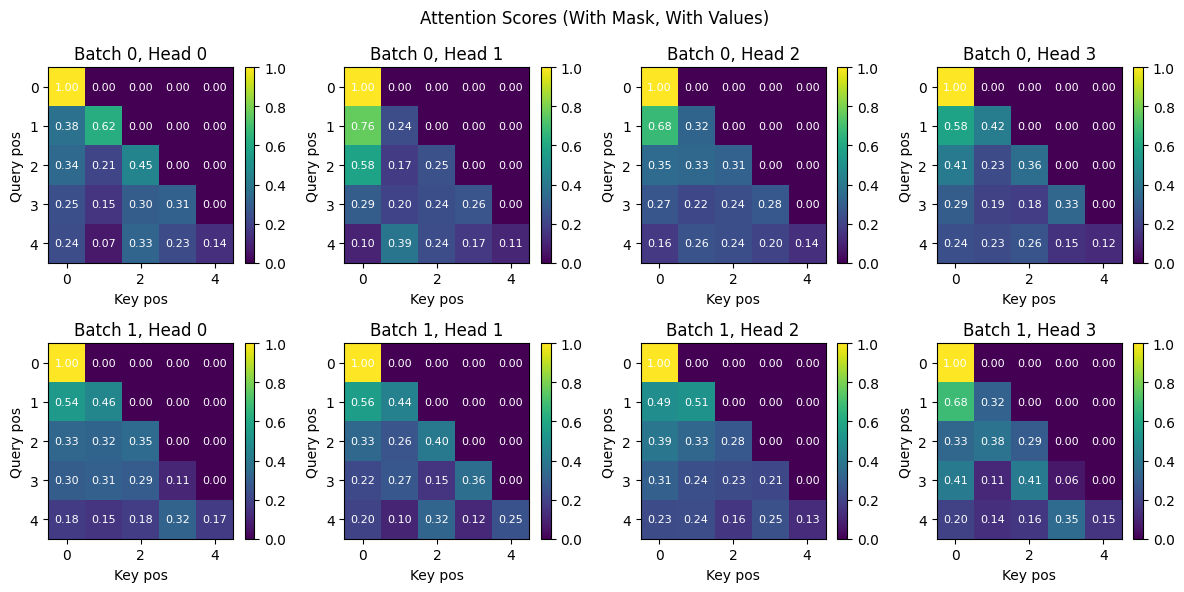

In [138]:
# 简单测试MultiHeadAttention模块
import torch
import torch.nn.functional as F

# 定义一个简单的配置
config = {
    "hidden_size": 16,
    "num_heads": 4
}

# 实例化MultiHeadAttention
mha = MultiHeadAttention(config)

# 构造输入数据
batch_size = 2
seq_len = 5
hidden_size = config["hidden_size"]

querys = torch.randn(batch_size, seq_len, hidden_size)
keys = torch.randn(batch_size, seq_len, hidden_size)
values = torch.randn(batch_size, seq_len, hidden_size)

# 不加mask的情况
output = mha(querys, keys, values)
print("hidden_states shape:", output.hidden_states.shape)
print("attn_scores shape:", output.attn_scores.shape)

# 加mask的情况
attn_mask = torch.zeros(batch_size, config["num_heads"], seq_len, seq_len)
# 构造lookahead mask（下三角为0，其余为1），即只能看到当前位置及之前
lookahead_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)  # shape: (seq_len, seq_len), 上三角为1
lookahead_mask = lookahead_mask.unsqueeze(0).unsqueeze(0)  # shape: (1, 1, seq_len, seq_len)
lookahead_mask = lookahead_mask.expand(batch_size, config["num_heads"], seq_len, seq_len)  # shape: (batch_size, num_heads, seq_len, seq_len)
attn_mask = lookahead_mask  # 用lookahead mask替换原来的mask

output_masked = mha(querys, keys, values, attn_mask=attn_mask)
print("With mask - hidden_states shape:", output_masked.hidden_states.shape)
print("With mask - attn_scores shape:", output_masked.attn_scores.shape)

import matplotlib.pyplot as plt

# 可视化 attn_scores
# 在每个格子里标注分数
def plot_attn_scores_with_values(attn_scores, title="Attention Scores"):
    # attn_scores: (batch_size, num_heads, seq_len_q, seq_len_k)
    batch_size, num_heads, seq_len_q, seq_len_k = attn_scores.shape
    fig, axes = plt.subplots(batch_size, num_heads, figsize=(num_heads*3, batch_size*3))
    if batch_size == 1:
        axes = [axes]
    for b in range(batch_size):
        for h in range(num_heads):
            ax = axes[b][h] if batch_size > 1 else axes[h]
            data = attn_scores[b, h].detach().cpu().numpy()
            im = ax.imshow(data, aspect='auto', cmap='viridis')
            ax.set_title(f"Batch {b}, Head {h}")
            ax.set_xlabel("Key pos")
            ax.set_ylabel("Query pos")
            # 在每个格子里标注分数
            for i in range(seq_len_q):
                for j in range(seq_len_k):
                    ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color="w", fontsize=8)
            fig.colorbar(im, ax=ax)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# 可视化未加mask的attn_scores并标注分数
plot_attn_scores_with_values(output.attn_scores, title="Attention Scores (No Mask, With Values)")

# 可视化加mask的attn_scores并标注分数
plot_attn_scores_with_values(output_masked.attn_scores, title="Attention Scores (With Mask, With Values)")



## transformer_block

In [139]:
@dataclass
class TransformerBlockOutput:
    hidden_states: Tensor
    self_attn_scores: Tensor
    cross_attn_scores: Optional[Tensor] = None

class TransformerBlock(nn.Module):
    def __init__(self, config, add_cross_attn:bool=False):
        super().__init__()
        self.hidden_size = config["hidden_size"]
        self.num_heads = config["num_heads"]
        self.dropout_rate = config["dropout_rate"]
        self.fnn_dim = config["fnn_dim"]
        eps = config["layer_norm_eps"]

        self.self_attn = MultiHeadAttention(config)
        self.self_ln = nn.LayerNorm(self.hidden_size, eps=eps)
        self.self_dropout = nn.Dropout(self.dropout_rate)

        if add_cross_attn:
            self.cross_attn = MultiHeadAttention(config)
            self.cross_ln = nn.LayerNorm(self.hidden_size, eps=eps)
            self.cross_dropout = nn.Dropout(self.dropout_rate)
        else:
            self.cross_attn = None

        self.ffn = nn.Sequential(
            nn.Linear(self.hidden_size, self.fnn_dim),
            nn.ReLU(),
            nn.Linear(self.fnn_dim, self.hidden_size),
        )

        self.ffn_ln = nn.LayerNorm(self.hidden_size, eps=eps)
        self.ffn_dropout = nn.Dropout(self.dropout_rate)

    def forward(
        self,
        hidden_states,
        attn_mask=None,
        encoder_output=None,
        cross_attn_mask=None,
    ):
        self_attn_output = self.self_attn(
            hidden_states,hidden_states,hidden_states,attn_mask=attn_mask
        )

        self_embeds = self.self_ln(
            hidden_states + self.self_dropout(self_attn_output.hidden_states)
        )
        if self.cross_attn is not None:
            assert encoder_output is not None, "encoder_output is required for cross-attention"
            cross_attn_output = self.cross_attn(
                self_embeds,encoder_output,encoder_output,attn_mask=cross_attn_mask
            )
            cross_embeds = self.cross_ln(
                self_embeds + self.cross_dropout(cross_attn_output.hidden_states)
            )

        embeds = cross_embeds if self.cross_attn is not None else self_embeds

        ffn_output = self.ffn(embeds)
        embeds = self.ffn_ln(embeds + self.ffn_dropout(ffn_output))

        return TransformerBlockOutput(
            hidden_states=embeds,
            self_attn_scores=self_attn_output.attn_scores,
            cross_attn_scores=cross_attn_output.attn_scores if self.cross_attn is not None else None
        )



## encoder

In [140]:
from typing import List

In [141]:
@dataclass
class TransformerEncoderOutput:
    last_hidden_state:Tensor
    attn_scores:List[Tensor]

class TransformerEncoder(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.num_layers = config["num_encoder_layers"]

        self.layers = nn.ModuleList([TransformerBlock(config) for _ in range(self.num_layers)])

    def forward(
        self,encoder_inputs_embeds,attn_mask=None
    ) -> TransformerEncoderOutput:
        attn_scores = []
        embeds = encoder_inputs_embeds

        for layer in self.layers:
            block_outputs = layer(embeds, attn_mask=attn_mask)
            embeds = block_outputs.hidden_states
            attn_scores.append(block_outputs.self_attn_scores)
            #block_outputs.self_attn_scores: (batch_size,num_heads,seq_len,seq_len)
        return TransformerEncoderOutput(
            last_hidden_state=embeds,
            attn_scores=attn_scores
        )



In [142]:
# # 一个简单的例子测试 TransformerEncoder 模块

# import torch
# import torch.nn as nn



# # 配置参数
# config = {
#     "num_layers": 2,
#     "hidden_size": 16,
#     "num_heads": 2,
#     "dropout_rate": 0.1,
#     "fnn_dim": 32,
#     "layer_norm_eps": 1e-5
# }

# # 构造输入
# batch_size = 4
# seq_len = 10
# hidden_size = config["hidden_size"]
# inputs = torch.randn(batch_size, seq_len, hidden_size)

# # 实例化并前向
# encoder = TransformerEncoder(config)
# output = encoder(inputs)

# print("last_hidden_state shape:", output.last_hidden_state.shape)
# print("attn_scores lens:", len(output.attn_scores))
# print("attn_scores[0] shape:", output.attn_scores[0].shape)


## decoder

In [143]:
@dataclass
class TransformerDecoderOutput:
    last_hidden_state:Tensor
    self_attn_scores:List[Tensor]
    cross_attn_scores:List[Tensor]

class TransformerDecoder(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.num_layers = config["num_decoder_layers"]
        self.layers = nn.ModuleList([TransformerBlock(config,add_cross_attn=True) for _ in range(self.num_layers)])

    def forward(
        self,
        decoder_inputs_embeds,
        encoder_outputs,
        attn_mask=None,
        cross_attn_mask=None
    ) -> TransformerDecoderOutput:
        self_attn_scores = []
        cross_attn_scores = []
        embeds = decoder_inputs_embeds

        for layer in self.layers:
            block_outputs = layer(embeds, attn_mask=attn_mask, encoder_output=encoder_outputs, cross_attn_mask=cross_attn_mask)
            embeds = block_outputs.hidden_states
            self_attn_scores.append(block_outputs.self_attn_scores)
            # assert block_outputs.cross_attn_scores is not None, "cross_attn_scores is None"
            cross_attn_scores.append(block_outputs.cross_attn_scores)

        return TransformerDecoderOutput(
            last_hidden_state=embeds,
            self_attn_scores=self_attn_scores,
            cross_attn_scores=cross_attn_scores
        )


In [144]:
# # 一个简单的例子测试 TransformerDecoder 模块

# # 配置参数
# config = {
#     "num_layers": 2,
#     "hidden_size": 16,
#     "num_heads": 2,
#     "dropout_rate": 0.1,
#     "fnn_dim": 32,
#     "layer_norm_eps": 1e-5
# }

# # 构造输入
# batch_size = 4
# tgt_seq_len = 8
# src_seq_len = 10
# hidden_size = config["hidden_size"]
# decoder_inputs_embeds = torch.randn(batch_size, tgt_seq_len, hidden_size)
# encoder_output = torch.randn(batch_size, src_seq_len, hidden_size)

# # 构造交叉注意力掩码（cross attention mask）
# # 假设为全1（即无mask），形状为 [batch_size, tgt_seq_len, src_seq_len]
# cross_attn_mask = torch.ones(batch_size, tgt_seq_len, src_seq_len)

# # 实例化并前向
# decoder = TransformerDecoder(config)
# output = decoder(
#     decoder_inputs_embeds=decoder_inputs_embeds,
#     encoder_output=encoder_output,
#     cross_attn_mask=cross_attn_mask
# )

# print("last_hidden_state shape:", output.last_hidden_state.shape)
# print("self_attn_scores lens:", len(output.self_attn_scores))
# print("self_attn_scores[0] shape:", output.self_attn_scores[0].shape)
# print("cross_attn_scores lens:", len(output.cross_attn_scores))
# # print("cross_attn_scores[0] shape:", output.cross_attn_scores[0].shape)

## transformer_model

In [ ]:
@dataclass
class TransformerOutput:
    logits:Tensor
    encoder_last_hidden_state:Tensor
    encoder_attn_scores:List[Tensor]
    decoder_last_hidden_state:Tensor
    decoder_self_attn_scores:List[Tensor]
    decoder_cross_attn_scores:List[Tensor]
    preds: Optional[Tensor] = None

class Transformer(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.hidden_size = config["hidden_size"]
        self.num_encoder_layers = config["num_encoder_layers"]
        self.num_decoder_layers = config["num_decoder_layers"]
        self.pad_idx = config["pad_idx"]
        self.bos_idx = config["bos_idx"]
        self.eos_idx = config["eos_idx"]
        self.vocab_size = config["vocab_size"]
        self.dropout_rate = config["dropout_rate"]
        self.max_length = config["max_length"]
        self.share_embedding = config["share_embedding"]

        self.src_embedding = TransformerEmbedding(config)
        if self.share_embedding:
            self.trg_embedding = self.src_embedding
            self.linear = lambda x: torch.matmul(x,self.trg_embedding.get_word_embedding().T)
        else:
            self.trg_embedding = TransformerEmbedding(config)
            self.linear = nn.Linear(self.hidden_size,self.vocab_size)

        self.encoder = TransformerEncoder(config)
        self.decoder = TransformerDecoder(config)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def generate_square_subsequent_mask(self,seq_len:int) -> Tensor:
        mask  = torch.triu(torch.ones(seq_len,seq_len),diagonal=1).bool()
        return mask

    def forward(
        self,
        encoder_inputs,
        decoder_inputs,
        encoder_inputs_mask=None
    ) -> TransformerOutput:
        if encoder_inputs_mask is None:
            encoder_inputs_mask = encoder_inputs.eq(self.pad_idx)
        encoder_inputs_mask = encoder_inputs_mask.unsqueeze(1).unsqueeze(2) #shape(batch_size,1,1,seq_len)

        look_ahead_mask = self.generate_square_subsequent_mask(decoder_inputs.shape[1])#shape: (seq_len,seq_len)
        look_ahead_mask = (
            look_ahead_mask.unsqueeze(0).unsqueeze(0).to(device) #shape: (1,1,seq_len,seq_len)
        )

        decoder_inputs_mask = decoder_inputs.eq(self.pad_idx).to(device)# shape: (batch_size,seq_len)
        decoder_inputs_mask = decoder_inputs_mask.unsqueeze(1).unsqueeze(2)
        # shape: (batch_size,1,seq_len,seq_len)
        decoder_inputs_mask = decoder_inputs_mask + look_ahead_mask

        encoder_inputs_embeds = self.src_embedding(encoder_inputs)
        encoder_outputs =self.encoder(encoder_inputs_embeds,attn_mask=encoder_inputs_mask)

        decoder_inputs_embeds = self.trg_embedding(decoder_inputs)
        decoder_outputs = self.decoder(
            decoder_inputs_embeds=decoder_inputs_embeds,
            encoder_outputs=encoder_outputs.last_hidden_state,
            attn_mask=decoder_inputs_mask,
            cross_attn_mask=encoder_inputs_mask
        )

        logits = self.linear(decoder_outputs.last_hidden_state)#shape: (batch_size,seq_len,vocab_size)


        return TransformerOutput(
            logits = logits,
            encoder_last_hidden_state = encoder_outputs.last_hidden_state,
            encoder_attn_scores = encoder_outputs.attn_scores,
            decoder_last_hidden_state = decoder_outputs.last_hidden_state,
            decoder_self_attn_scores = decoder_outputs.self_attn_scores,
            decoder_cross_attn_scores = decoder_outputs.cross_attn_scores,
        )

    @torch.no_grad()
    def infer(self,encoder_inputs,encoder_inputs_mask=None) -> Tensor:
        if encoder_inputs_mask is None:
            encoder_inputs_mask = encoder_inputs.eq(self.pad_idx)
        encoder_inputs_mask = encoder_inputs_mask.unsqueeze(1).unsqueeze(2) #shape(batch_size,1,1,seq_len)
        look_ahead_mask = self.generate_square_subsequent_mask(self.max_length)
        look_ahead_mask = (
            look_ahead_mask.unsqueeze(0).unsqueeze(0).to(device) #shape: (1,1,seq_len,seq_len)
        )

        encoder_inputs_embeds = self.src_embedding(encoder_inputs)
        encoder_outputs = self.encoder(encoder_inputs_embeds)

        decoder_inputs = torch.tensor([[self.bos_idx]]*encoder_inputs.size(0)).long().to(device)
        for cur_len in range(1,self.max_length+1):
            decoder_inputs_embeds = self.trg_embedding(decoder_inputs)
            decoder_outputs = self.decoder(
                decoder_inputs_embeds=decoder_inputs_embeds,
                encoder_outputs=encoder_outputs.last_hidden_state,
                attn_mask=look_ahead_mask[:,:,:cur_len,:cur_len],
            )

            logits = self.linear(decoder_outputs.last_hidden_state)
            next_token = logits.argmax(dim=-1)[:,-1:]
            decoder_inputs = torch.cat([decoder_inputs,next_token],dim=1)

            if all((decoder_inputs == self.eos_idx).sum(dim=-1)>0):
                break

        return TransformerOutput(
            preds=decoder_inputs[:,1:],
            logits=logits,
            encoder_last_hidden_state=encoder_outputs.last_hidden_state,
            encoder_attn_scores=encoder_outputs.attn_scores,
            decoder_last_hidden_state=decoder_outputs.last_hidden_state,
            decoder_self_attn_scores=decoder_outputs.self_attn_scores,
            decoder_cross_attn_scores=decoder_outputs.cross_attn_scores
        )


In [146]:
import torch

# 假设 device 已经定义
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 构造一个简单的 config
config = {
    "hidden_size": 32,
    "num_encoder_layers": 2,
    "num_decoder_layers": 2,
    "pad_idx": 0,
    "bos_idx": 1,
    "eos_idx": 2,
    "vocab_size": 100,
    "dropout_rate": 0.1,
    "max_length": 10,
    "share_embedding": False,
    "num_heads": 2,
    "fnn_dim": 32,
    "layer_norm_eps": 1e-5
}

# 实例化模型
model = Transformer(config).to(device)

# 构造简单的输入
batch_size = 1
src_seq_len = 6
trg_seq_len = 5

# 随机生成输入序列，pad_idx=0
encoder_inputs = torch.randint(3, config["vocab_size"], (batch_size, src_seq_len)).to(device)
decoder_inputs = torch.randint(3, config["vocab_size"], (batch_size, trg_seq_len)).to(device)

# 前向运算
output = model(encoder_inputs, decoder_inputs)

# 打印输出的主要内容
print("logits shape:", output.logits.shape)
print("encoder_last_hidden_state shape:", output.encoder_last_hidden_state.shape)
print("decoder_last_hidden_state shape:", output.decoder_last_hidden_state.shape)
print("encoder_attn_scores lens:", output.encoder_attn_scores[0].shape)
print("decoder_self_attn_scores lens:", len(output.decoder_self_attn_scores))
print("decoder_cross_attn_scores lens:", len(output.decoder_cross_attn_scores))


logits shape: torch.Size([1, 5, 100])
encoder_last_hidden_state shape: torch.Size([1, 6, 32])
decoder_last_hidden_state shape: torch.Size([1, 5, 32])
encoder_attn_scores lens: torch.Size([1, 2, 6, 6])
decoder_self_attn_scores lens: 2
decoder_cross_attn_scores lens: 2


## 交叉熵损失函数

In [147]:
class CrossEntropyWithPadding:
    def __init__(self,config):
        self.label_smoothing = config["label_smoothing"]

    def __call__(self,logits,targets,padding_mask=None):
        bs ,seq_len, vocab_size = logits.shape
        loss = F.cross_entropy(logits.view(-1,vocab_size),targets.view(-1),reduce=False,label_smoothing=self.label_smoothing)
        if padding_mask is not None:
            loss = loss.mean()
        else:
            padding_mask  = 1 - padding_mask.reshape(-1)
            loss = torch.mul(loss,padding_mask).sum()/padding_mask.sum()
        return loss


## 学习率衰减

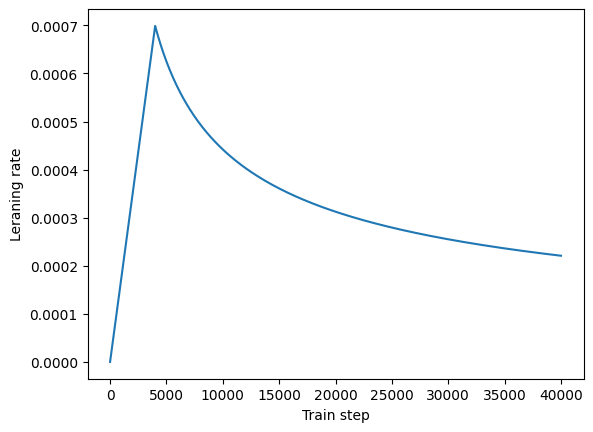

In [148]:
class NoamDecayScheduler:
    def __init__(self,config):
        self.hidden_size = config["hidden_size"]
        self.warmup_steps = config["warmup_steps"]

    def __call__(self,step):
        step += 1
        arg1 = step ** (-0.5)
        arg2 = step * (self.warmup_steps ** (-1.5))
        return (self.hidden_size ** (-0.5)) *np.minimum(arg1,arg2)

temp_learning_rate_schedule = NoamDecayScheduler({"hidden_size": 512, "warmup_steps": 4000})
plt.plot(temp_learning_rate_schedule(np.arange(0, 40000)))
plt.ylabel("Leraning rate")
plt.xlabel("Train step")
plt.show()

## 优化器

In [149]:
from torch.optim.lr_scheduler import LambdaLR
from torch.optim import Adam

In [150]:
def get_optimizer(model,config):
    base_lr = 0.1
    beta1 = config["beta1"]
    beta2 = config["beta2"]
    eps = config["eps"]
    optimizer = Adam(model.parameters(),lr=base_lr,betas=(beta1,beta2),eps=eps)
    lr_scheduler = NoamDecayScheduler(config)
    scheduler = LambdaLR(optimizer,lr_lambda=lr_scheduler)
    return optimizer,scheduler

# 早停，保存

In [151]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = - np.inf
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


In [152]:
import os
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = - np.inf

        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))

## 开始学习

In [153]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    for batch in dataloader:
        encoder_inputs = batch["encoder_inputs"]
        encoder_inputs_mask = batch["encoder_inputs_mask"]
        decoder_inputs = batch["decoder_inputs"]
        decoder_labels = batch["decoder_labels"]
        decoder_labels_mask = batch["decoder_labels_mask"]

        # 前向计算
        outputs = model(
            encoder_inputs,
            decoder_inputs,
            encoder_inputs_mask
            )
        logits = outputs.logits
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)         # 验证集损失
        loss_list.append(loss.cpu().item())

    return np.mean(loss_list)


In [154]:
# 训练
from pyarrow import total_allocated_bytes


def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    scheduler=None,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }

    global_step = 1
    val_loss = 0
    model.train()
    total = 0
    with tqdm(total = total+epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for batch in train_loader:
                encoder_inputs = batch["encoder_inputs"]
                encoder_inputs_mask = batch["encoder_inputs_mask"]
                decoder_inputs = batch["decoder_inputs"]
                decoder_labels = batch["decoder_labels"]
                decoder_labels_mask = batch["decoder_labels_mask"]
                # 梯度清空
                optimizer.zero_grad()

                # 前向计算
                outputs = model(
                    encoder_inputs,
                    decoder_inputs,
                    encoder_inputs_mask
                    )
                logits = outputs.logits
                loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

                # 梯度回传
                loss.backward()

                # 调整优化器，包括学习率的变动等
                optimizer.step()
                if scheduler is not None:
                    scheduler.step() # 更新学习率,学习率就会传递给optimizer

                loss = loss.cpu().item()
                # record
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })

                # evaluating
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train()

                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # udate step
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id, "loss": loss, "val_loss": val_loss})

    return record_dict


In [155]:
config = {
    "hidden_size": 512,
    "num_encoder_layers": 4,
    "num_decoder_layers": 4,
    "pad_idx": 0,
    "bos_idx": 1,
    "eos_idx": 3,
    "vocab_size": vocab_size,
    "dropout_rate": 0.2,
    "max_length": 200,
    "share_embedding": False,
    "num_heads": 8,
    "fnn_dim": 512,
    "layer_norm_eps": 1e-5,
    "label_smoothing": 0.1,
    "warmup_steps": 4000,
    "beta1": 0.9,
    "beta2": 0.98,
    "eps": 1e-9
}
# 数据加载器
def get_dl(dataset, batch_size, shuffle=True):
    sampler = TransformerBatchSampler(dataset, batch_size=batch_size, shuffle_batch=shuffle)
    sample_dl = DataLoader(dataset, batch_sampler=sampler, collate_fn=partial(collate_fct, tokenizer=tokenizer))
    return sample_dl

# dataset
train_ds = LangPairDataset("train", max_length=config["max_length"])
val_ds = LangPairDataset("val", max_length=config["max_length"])
# tokenizer
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word, max_length=config["max_length"])
batch_size = 4096
# dataloader
train_dl = get_dl(train_ds, batch_size=batch_size, shuffle=True)
val_dl = get_dl(val_ds, batch_size=batch_size, shuffle=False)


Loading cached data from wmt16/.cache/de2en_train_max200.npy...
Loading cached data from wmt16/.cache/de2en_val_max200.npy...


In [156]:
model = Transformer(config)
optimizer,scheduler = get_optimizer(model,config)
loss_fct = CrossEntropyWithPadding(config)
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback(
    f"checkpoints", save_step=500, save_best_only=True)
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=8)

model = model.to(device)
num_epochs = 50
epoch = 20
record = training(
    model,
    train_dl,
    val_dl,
    epoch,
    loss_fct,
    optimizer,
    scheduler,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=None,
    eval_step=500
    )

  0%|          | 0/160 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


In [157]:
from functools import partial

In [158]:
train_ds = LangPairDataset(mode="train")
val_ds = LangPairDataset(mode="val")
test_ds = LangPairDataset(mode="test")

Loading cached data from wmt16/.cache/de2en_train_max128.npy...
Loading cached data from wmt16/.cache/de2en_val_max128.npy...
Loading cached data from wmt16/.cache/de2en_test_max128.npy...


In [159]:
batch_size = 8192
train_sample = TransformerBatchSampler(train_ds,batch_size=batch_size,shuffle_batch=True)
val_sample = TransformerBatchSampler(val_ds,batch_size=batch_size,shuffle_batch=False)
test_sample = TransformerBatchSampler(test_ds,batch_size=batch_size,shuffle_batch=False)

In [160]:
train_loader = DataLoader(train_ds,batch_sampler=train_sample,collate_fn=partial(collate_fct,tokenizer=tokenizer))
val_loader = DataLoader(val_ds,batch_sampler=val_sample,collate_fn=partial(collate_fct,tokenizer=tokenizer))
test_loader = DataLoader(test_ds,batch_sampler=test_sample,collate_fn=partial(collate_fct,tokenizer=tokenizer))

In [161]:
# model,history = trainer.train_for_transformer(train_loader,val_loader,scheduler)

In [162]:
# trainer.plot_history(mode='1')

In [163]:
# trainer.evaluate_for_transformer(model,test_loader)

# 载入模型


In [166]:
model.load_state_dict(torch.load("checkpoints/best.ckpt",map_location=device))
print(f"模型载入完成")

模型载入完成


In [167]:
raw_text = ["ein mann mit einem orangefarbenen hut , der etwas anst@@ arr@@ t ."]
encoder_inputs= tokenizer.encode(raw_text,add_bos=True,add_eos=True,return_mask_flag=False)
print(encoder_inputs)
encoder_inputs_decoder = tokenizer.decode(encoder_inputs)
print(f"raw text:",raw_text[0])
print(encoder_inputs_decoder)

tensor([[    1,     7,    17,    13,     8,   360,   199,     9,    24,   145,
         11796, 11412,   916,     4,     3]])
raw text: ein mann mit einem orangefarbenen hut , der etwas anst@@ arr@@ t .
['ein mann mit einem orangefarbenen hut , der etwas anst@@ arr@@ t .']


In [168]:
# 选择10句德语
de_sentences = [
    "ein mann mit einem orangefarbenen hut , der etwas anst@@ arr@@ t .",
    "mehrere männer mit schutzhelmen bedienen ein antriebsradsystem .",
    "ein kleines mädchen klettert in ein spielhaus aus holz .",
    "ein mann in einem blauen hemd steht auf einer leiter und putzt ein fenster .",
    "zwei männer stehen am herd und bereiten essen zu .",
    "ein mann in grün hält eine gitarre , während der andere mann sein hemd ansieht .",
    "ein mann lächelt einen ausgestopften löwen an .",
    "ein schickes mädchen spricht mit dem handy während sie langsam die straße entlangschwebt .",
    "eine frau mit einer großen geldbörse geht an einem tor vorbei .",
    "jungen tanzen mitten in der nacht auf pfosten ."
]

# 编码德语句子
de_inputs = tokenizer.encode(de_sentences, add_bos=True, add_eos=True, return_mask_flag=False)
# print(de_inputs)
# 转为tensor，形状为(batch_size, seq_len)
src = torch.tensor(de_inputs, dtype=torch.long, device=device)
# print(src)
# 推断
model.eval()
model = model.to(device)
with torch.no_grad():
    output_ids = model.infer(src)  # 直接调用infer，输出为(batch_size, seq_len)
print("hi")
# 解码输出
en_sentences = tokenizer.decode(output_ids.preds)

# 打印结果
for de, en in zip(de_sentences, en_sentences):
    print("德语:", de)
    print("英语:", en)
    print("-" * 40)


/tmp/ipython-input-168-1440561674.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  src = torch.tensor(de_inputs, dtype=torch.long, device=device)


hi
德语: ein mann mit einem orangefarbenen hut , der etwas anst@@ arr@@ t .
英语: a man in an orange hat who is dressed in his clothing &apos;s robe .
----------------------------------------
德语: mehrere männer mit schutzhelmen bedienen ein antriebsradsystem .
英语: several men in hard hats are putting a turn against the same van .
----------------------------------------
德语: ein kleines mädchen klettert in ein spielhaus aus holz .
英语: a little girl climbs into a wooden structure of wood that is juggling .
----------------------------------------
德语: ein mann in einem blauen hemd steht auf einer leiter und putzt ein fenster .
英语: a man in a blue shirt is standing on a ladder cleaning a window .
----------------------------------------
德语: zwei männer stehen am herd und bereiten essen zu .
英语: two men are standing at the stove preparing food to be a podium .
----------------------------------------
德语: ein mann in grün hält eine gitarre , während der andere mann sein hemd ansieht .
英语: a man 

In [169]:
class Translator:
    def __init__(self, model, src_tokenizer, trg_tokenizer, device=None):
        # device: torch.device, e.g. torch.device('cuda') or torch.device('cpu')
        if device is None:
            # 自动检测cuda
            self.device = next(model.parameters()).device
        else:
            self.device = device
        self.model = model.to(self.device)
        self.model.eval()
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

    def __call__(self, sentence):
        return self.translate(sentence)

    def translate(self, sentences):
        sentences = [sentence for sentence in sentences]
        # 保证tokenizer输出在正确设备上
        src_ids, src_mask = self.src_tokenizer.encode(
            sentences, add_bos=True, add_eos=True, return_mask_flag=True
        )
        src_ids = src_ids.to(device=self.device)
        if src_mask is not None:
            src_mask = src_mask.to(device=self.device)
        result= self.model.infer(src_ids).preds
        result = self.trg_tokenizer.decode(result)
        # attn_weights = attn_weights.detach().to('cpu').numpy()[0]
        return result

    # 修改draw_attention函数，使热力图每个格子都显示注意力数值，并添加颜色尺标
    def draw_attention(self, attn_weights, src_list, trg_list):
        import matplotlib.pyplot as plt
        import numpy as np

        # 确保attn_weights在cpu并为numpy数组
        if hasattr(attn_weights, "detach"):
            attn_weights = attn_weights.detach().to('cpu').numpy()
        elif hasattr(attn_weights, "cpu"):
            attn_weights = attn_weights.cpu().numpy()
        # 兼容单样本情况
        if attn_weights.ndim == 3:
            attn_weights = attn_weights[0]

        fig, ax = plt.subplots(figsize=(len(src_list)*0.7+2, len(trg_list)*0.7+2))
        cax = ax.matshow(attn_weights, cmap='viridis')
        fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)  # 添加颜色尺标
        ax.set_title("Attention Heatmap between Spanish Source and English Target")
        ax.set_xticks(range(len(src_list)))
        ax.set_yticks(range(len(trg_list)))
        ax.set_xticklabels(src_list, ha='left', fontsize=10)
        ax.set_yticklabels(trg_list, fontsize=10)
        ax.set_ylabel("Target (English)")
        ax.set_xlabel("Source (Spanish)")

        # 在每个格子上显示注意力数值
        for i in range(attn_weights.shape[0]):
            for j in range(attn_weights.shape[1]):
                value = attn_weights[i, j]
                ax.text(j, i, f"{value:.2f}", va='center', ha='center', color='w' if value < 0.5 else 'black', fontsize=8)

        plt.tight_layout()
        plt.show()

In [170]:
translator = Translator(model,tokenizer,tokenizer)

from nltk.translate.bleu_score import sentence_bleu

def evaluate_bleu_on_test_set(test_data, translation):
    total_bleu = 0.0
    num_samples = len(test_data)
    i=0
    for src_sentence, ref_translations in test_data:
        # print(f"ref_translations{ref_translations}")
        # print(f"src_sentence:{src_sentence}")
        candidate_translation = translation.translate([src_sentence])
        # print(i)
        # print(f"src_sentence:{src_sentence}")
        # print(f"candidate_translation:{candidate_translation}")
        # print(f"ref_translations:{ref_translations}")
        # print("-"*50)
        candidate_sentence = candidate_translation[0].strip().split()
        ref_translations = [ref_translations.strip().split()]
        # print(f"ref_translations:{ref_translations}")
        # print(f"candidate_sentence:{candidate_sentence}")
        bleu_score = sentence_bleu(
            ref_translations,
            candidate_sentence,
            weights=(1, 0, 0, 0)
        )
        # print(f"i,bleu_score:{bleu_score}")
        total_bleu += bleu_score
        # i += 1
        # if i == num_samples:
        #   break
    avg_bleu = total_bleu / num_samples
    return avg_bleu
avg_bleu=evaluate_bleu_on_test_set(test_ds, translator)
print(f"bleu_score={avg_bleu}")







/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

bleu_score=0.6392826338603287


In [172]:
from nltk.translate.bleu_score import sentence_bleu

def evaluate_bleu_on_test_set(test_data, translation):
    total_bleu = 0.0
    num_samples = len(test_data)
    i=0
    for src_sentence, ref_translations in test_data:
        # print(f"ref_translations{ref_translations}")
        # print(f"src_sentence:{src_sentence}")
        candidate_translation = translation.translate([src_sentence])
        # print(i)
        # print(f"src_sentence:{src_sentence}")
        # print(f"candidate_translation:{candidate_translation}")
        # print(f"ref_translations:{ref_translations}")
        # print("-"*50)
        candidate_sentence = candidate_translation[0].strip().split()
        ref_translations = [ref_translations.strip().split()]
        # print(f"ref_translations:{ref_translations}")
        # print(f"candidate_sentence:{candidate_sentence}")
        bleu_score = sentence_bleu(
            ref_translations,
            candidate_sentence,
            weights=(0.25, 0.25, 0.25, 0.25)
        )
        # print(f"i,bleu_score:{bleu_score}")
        total_bleu += bleu_score
        # i += 1
        # if i == num_samples:
        #   break
    avg_bleu = total_bleu / num_samples
    return avg_bleu
avg_bleu=evaluate_bleu_on_test_set(test_ds, translator)
print(f"bleu4_score={avg_bleu}")

bleu4_score=0.2782976722641928
